# 03. Statistical Analysis
## Structural Health Monitoring — Heritage Masonry Vaults

**Purpose:** Load all 12 clean sensor CSVs, merge into a unified DataFrame, and compute
comparative statistical analysis across all sensors and structural zones.

**Input:** `../data/processed/clean_{sensor}.csv` — 12 clean CSVs from `02_data_cleaning.ipynb`

**Output:**
- `../outputs/tables/02_clean_data_nan_summary.xlsx` — null count table on clean data
- `../outputs/tables/03_statistics_summary_all_sensors.xlsx` — descriptive statistics per sensor
- `../outputs/tables/03_movement_ranges_consolidated.xlsx` — percentile range table
- `../outputs/tables/03_total_displacement_comparison.png` — comparative bar chart
- `../outputs/tables/03_std_dev_comparison.png` — std deviation bar chart

**Next notebook:** `04_correlation_analysis.ipynb`

---
## 0. Configuration

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd              # DataFrame handling and manipulation
import numpy as np               # Mathematical functions
import matplotlib.pyplot as plt  # Graphs
import seaborn as sns            # Graphs
import os                        # Directory and path management
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from datetime import datetime

# ============================================================
# SENSOR CONFIGURATION
# ============================================================
SENSORS = ['S01', 'S02', 'S03', 'S04', 'S05', 'S06',
           'S07', 'S08', 'S09', 'S10', 'S11', 'S12']

SENSOR_CONFIG = {
    'S01': {'zone': 'Zone A', 'axis': 'Diag.', 'color': '#0563C1'},
    'S02': {'zone': 'Zone A', 'axis': 'Hor.',  'color': '#ADD8E6'},
    'S03': {'zone': 'Zone A', 'axis': 'Diag.', 'color': '#0563C1'},
    'S04': {'zone': 'Zone A', 'axis': 'Hor.',  'color': '#ADD8E6'},
    'S05': {'zone': 'Zone B', 'axis': 'Diag.', 'color': '#FFA500'},
    'S06': {'zone': 'Zone B', 'axis': 'Hor.',  'color': '#FFD580'},
    'S07': {'zone': 'Zone B', 'axis': 'Diag.', 'color': '#FFA500'},
    'S08': {'zone': 'Zone B', 'axis': 'Hor.',  'color': '#FFD580'},
    'S09': {'zone': 'Zone C', 'axis': 'Diag.', 'color': '#6EAB54'},
    'S10': {'zone': 'Zone C', 'axis': 'Hor.',  'color': '#B6D5A9'},
    'S11': {'zone': 'Zone C', 'axis': 'Diag.', 'color': '#6EAB54'},
    'S12': {'zone': 'Zone C', 'axis': 'Hor.',  'color': '#B6D5A9'},
}

# ============================================================
# PATHS
# ============================================================
PROCESSED_DATA_PATH = '../data/processed/'
TABLES_PATH         = '../outputs/tables/'
os.makedirs(TABLES_PATH, exist_ok=True)

print('Configuration loaded.')
print(f'Sensors: {SENSORS}')

Configuration loaded.
Sensors: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12']


---
## 1. Load and Merge Clean Sensor CSVs

Each sensor has its own clean CSV produced by `02_data_cleaning.ipynb`.
This section merges all 12 into a single unified DataFrame for comparative analysis.

In [2]:
# ============================================================
# LOAD CLEAN CSVs AND MERGE
# Base: environmental variables from first sensor file
# Then: merge each sensor column individually by Timestamp
# ============================================================
first_path = os.path.join(PROCESSED_DATA_PATH, f'clean_S01.csv')
df_base = pd.read_csv(first_path)
df_base['Timestamp'] = pd.to_datetime(df_base['Timestamp'])

# Convert environmental columns to numeric
for col in ['Hum.', 'Pres.', 'Temp.']:
    df_base[col] = pd.to_numeric(df_base[col], errors='coerce')

# Start with Timestamp + environmental variables
df_limpio = df_base[['Timestamp', 'Hum.', 'Pres.', 'Temp.']].drop_duplicates(
    subset=['Timestamp']).set_index('Timestamp')

# Merge each sensor column
for sensor in SENSORS:
    path = os.path.join(PROCESSED_DATA_PATH, f'clean_{sensor}.csv')
    df_temp = pd.read_csv(path)
    df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'])
    df_temp[sensor] = pd.to_numeric(df_temp[sensor], errors='coerce')
    df_sensor = df_temp[['Timestamp', sensor]].drop_duplicates(
        subset=['Timestamp']).set_index('Timestamp')
    df_limpio = pd.merge(df_limpio, df_sensor, left_index=True, right_index=True, how='outer')

# Reset index and sort chronologically
df_limpio = df_limpio.reset_index().sort_values(by='Timestamp').reset_index(drop=True)

df_limpio.info()
print(f'\nDate range: {df_limpio["Timestamp"].min()} to {df_limpio["Timestamp"].max()}')
df_limpio.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 3463 entries, 0 to 3462
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  3463 non-null   datetime64[us]
 1   Hum.       3284 non-null   float64       
 2   Pres.      3284 non-null   float64       
 3   Temp.      3284 non-null   float64       
 4   S01        3300 non-null   float64       
 5   S02        3349 non-null   float64       
 6   S03        3179 non-null   float64       
 7   S04        3197 non-null   float64       
 8   S05        2167 non-null   float64       
 9   S06        2006 non-null   float64       
 10  S07        2783 non-null   float64       
 11  S08        2454 non-null   float64       
 12  S09        976 non-null    float64       
 13  S10        3376 non-null   float64       
 14  S11        3420 non-null   float64       
 15  S12        3243 non-null   float64       
dtypes: datetime64[us](1), float64(15)
memory usage: 433.0

,Timestamp,Hum.,Pres.,Temp.,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12
0,2025-04-01 13:00:00,45.17,1013.69,28.37,12633.00,24680.60,12754.00,24675.00,11883.71,24646.73,11247.00,24669.23,12633.12,24619.93,12413.92,24644.83
1,2025-04-01 15:00:00,37.04,1011.57,33.41,12632.06,24681.70,12753.80,24675.95,11882.20,24647.19,11247.79,24669.80,12631.62,24620.00,12413.78,24645.00
2,2025-04-01 17:00:00,37.26,1010.26,31.13,12633.50,24682.00,12751.91,24676.00,11880.25,24647.37,11248.00,24671.00,12628.79,24619.90,12411.04,24645.27
3,2025-04-01 19:00:00,41.91,1009.54,28.28,12632.71,24681.96,12750.35,24676.64,11879.00,24646.75,11246.26,24672.00,12626.81,24619.89,12409.42,24646.00
4,2025-04-01 21:00:00,45.88,1009.84,26.78,12632.45,24681.57,12750.18,24677.00,11879.00,24646.89,11246.00,24671.68,12624.68,24619.92,12408.92,24645.00


---
## 2. Null Value Summary — Clean Data

Same structure as the raw null table from `01_data_ingestion.ipynb`.
Comparison between raw and clean null percentages reveals the impact of the cleaning pipeline.

In [3]:
# ============================================================
# NULL VALUE SUMMARY — CLEAN DATA
# ============================================================
df = df_limpio.copy()

total_timestamps = df['Timestamp'].count()

datos_tabla = []
for sensor in SENSORS:
    valid   = df[sensor].count()
    nulls   = df[sensor].isna().sum()
    pct_v   = round(valid / total_timestamps * 100, 2)
    pct_n   = round(nulls / total_timestamps * 100, 2)
    datos_tabla.append({
        'Sensor'            : sensor,
        'Zone'              : SENSOR_CONFIG[sensor]['zone'],
        'Axis'              : SENSOR_CONFIG[sensor]['axis'],
        'Valid Records'     : valid,
        'Null Records'      : nulls,
        '% Valid'           : pct_v,
        '% Null vs Timestamp': pct_n
    })

tabla_nan = pd.DataFrame(datos_tabla)
print(f'Total timestamps: {total_timestamps}')
print(f'Date range: {df["Timestamp"].min()} to {df["Timestamp"].max()}\n')
print(tabla_nan.to_string(index=False))

tabla_nan.to_excel(os.path.join(TABLES_PATH, '02_clean_data_nan_summary.xlsx'), index=False)
print(f'\nExported: 02_clean_data_nan_summary.xlsx')

Total timestamps: 3463
Date range: 2025-04-01 13:00:00 to 2026-02-27 23:29:30

Sensor   Zone  Axis  Valid Records  Null Records  % Valid  % Null vs Timestamp
   S01 Zone A Diag.           3300           163    95.29                 4.71
   S02 Zone A  Hor.           3349           114    96.71                 3.29
   S03 Zone A Diag.           3179           284    91.80                 8.20
   S04 Zone A  Hor.           3197           266    92.32                 7.68
   S05 Zone B Diag.           2167          1296    62.58                37.42
   S06 Zone B  Hor.           2006          1457    57.93                42.07
   S07 Zone B Diag.           2783           680    80.36                19.64
   S08 Zone B  Hor.           2454          1009    70.86                29.14
   S09 Zone C Diag.            976          2487    28.18                71.82
   S10 Zone C  Hor.           3376            87    97.49                 2.51
   S11 Zone C Diag.           3420            43    

---
## 3. Statistical Analysis — All Sensors

Computes descriptive statistics on relative displacement (movement from minimum reference)
for all 12 sensors. Results stored in `resultados_todos` dictionary for use in subsequent sections.

In [4]:
# ============================================================
# STATISTICAL ANALYSIS — ALL SENSORS
# Relative displacement = sensor value - minimum reference
# ============================================================
resultados_todos = {}

for sensor in SENSORS:
    print(f"\n{'='*120}")
    print(f"ANALYZING: {sensor} {SENSOR_CONFIG[sensor]['axis']} | {SENSOR_CONFIG[sensor]['zone']}")
    print(f"{'='*120}\n")

    datos = df[sensor].dropna().copy()

    if len(datos) == 0:
        print(f"  No data available for {sensor}")
        continue

    # Relative displacement from structural minimum
    datos_min        = datos.min()
    datos_max        = datos.max()
    movimiento_total = datos_max - datos_min
    datos_movimiento = datos - datos_min

    # Percentiles
    p1    = float(datos_movimiento.quantile(0.01))
    p2_5  = float(datos_movimiento.quantile(0.025))
    p5    = float(datos_movimiento.quantile(0.05))
    p10   = float(datos_movimiento.quantile(0.10))
    Q1    = float(datos_movimiento.quantile(0.25))
    p50   = float(datos_movimiento.quantile(0.50))
    Q3    = float(datos_movimiento.quantile(0.75))
    p90   = float(datos_movimiento.quantile(0.90))
    p95   = float(datos_movimiento.quantile(0.95))
    p97_5 = float(datos_movimiento.quantile(0.975))
    p99   = float(datos_movimiento.quantile(0.99))

    coef_var = (datos_movimiento.std() / datos_movimiento.mean() * 100) if datos_movimiento.mean() != 0 else 0

    resultados_todos[sensor] = {
        'zone': SENSOR_CONFIG[sensor]['zone'],
        'axis': SENSOR_CONFIG[sensor]['axis'],
        'datos_min': datos_min, 'datos_max': datos_max,
        'movimiento_total': movimiento_total,
        'media': datos_movimiento.mean(),
        'std': datos_movimiento.std(),
        'coef_var': coef_var,
        'p1': p1, 'p2_5': p2_5, 'p5': p5, 'p10': p10,
        'Q1': Q1, 'p50': p50, 'Q3': Q3,
        'p90': p90, 'p95': p95, 'p97_5': p97_5, 'p99': p99,
        'IQR': Q3 - Q1,
        'n_datos': len(datos)
    }

    print(f"""
STRUCTURAL DISPLACEMENT STATISTICS — {sensor} {SENSOR_CONFIG[sensor]['axis']} | {SENSOR_CONFIG[sensor]['zone']}:

GENERAL MOVEMENT:
  Records analyzed:      {len(datos)}
  Minimum detected:      0.00 mm (reference point)
  Maximum detected:      {movimiento_total:.2f} mm
  Average displacement:  {datos_movimiento.mean():.2f} mm
  Std. Dev.:             {datos_movimiento.std():.2f} mm
  Coeff. of Variation:   {coef_var:.2f}%

PERCENTILES (relative displacement):
  P1: {p1:.2f} mm    P99: {p99:.2f} mm
  P5: {p5:.2f} mm    P95: {p95:.2f} mm
  Q1: {Q1:.2f} mm    Q3:  {Q3:.2f} mm
  Median (P50): {p50:.2f} mm

CHARACTERISTIC MOVEMENT RANGES:
  50% central (IQR): {Q1:.2f} to {Q3:.2f} mm  (amplitude {Q3-Q1:.2f} mm)
  90% central:       {p5:.2f} to {p95:.2f} mm  (amplitude {p95-p5:.2f} mm)
  95% central:       {p2_5:.2f} to {p97_5:.2f} mm  (amplitude {p97_5-p2_5:.2f} mm)

ABSOLUTE VALUES:
  Absolute min: {datos_min:.2f} mm    Absolute max: {datos_max:.2f} mm
  Absolute mean: {datos.mean():.2f} mm
""")

print(f"{'='*120}")
print(f"ANALYSIS COMPLETE — {len(resultados_todos)} sensors processed")
print(f"{'='*120}")


ANALYZING: S01 Diag. | Zone A


STRUCTURAL DISPLACEMENT STATISTICS — S01 Diag. | Zone A:

GENERAL MOVEMENT:
  Records analyzed:      3300
  Minimum detected:      0.00 mm (reference point)
  Maximum detected:      5.62 mm
  Average displacement:  2.28 mm
  Std. Dev.:             0.92 mm
  Coeff. of Variation:   40.45%

PERCENTILES (relative displacement):
  P1: 0.62 mm    P99: 5.24 mm
  P5: 0.98 mm    P95: 3.98 mm
  Q1: 1.62 mm    Q3:  2.69 mm
  Median (P50): 2.15 mm

CHARACTERISTIC MOVEMENT RANGES:
  50% central (IQR): 1.62 to 2.69 mm  (amplitude 1.07 mm)
  90% central:       0.98 to 3.98 mm  (amplitude 3.00 mm)
  95% central:       0.76 to 4.62 mm  (amplitude 3.86 mm)

ABSOLUTE VALUES:
  Absolute min: 12630.38 mm    Absolute max: 12636.00 mm
  Absolute mean: 12632.66 mm


ANALYZING: S02 Hor. | Zone A


STRUCTURAL DISPLACEMENT STATISTICS — S02 Hor. | Zone A:

GENERAL MOVEMENT:
  Records analyzed:      3349
  Minimum detected:      0.00 mm (reference point)
  Maximum detected:      6.

---
## 4. Comparative Summary Table — All Sensors

In [5]:
# ============================================================
# COMPARATIVE SUMMARY TABLE — ALL SENSORS
# ============================================================
resumen_sensores = []
for s, d in resultados_todos.items():
    resumen_sensores.append({
        'Sensor'                 : s,
        'Zone'                   : d['zone'],
        'Axis'                   : d['axis'],
        'Records'                : d['n_datos'],
        'Absolute Min (mm)'      : f"{d['datos_min']:.2f}",
        'Absolute Max (mm)'      : f"{d['datos_max']:.2f}",
        'Total Displacement (mm)': f"{d['movimiento_total']:.2f}",
        'Mean Displacement (mm)' : f"{d['media']:.2f}",
        'Std. Dev. (mm)'         : f"{d['std']:.2f}",
        'Coeff. of Variation (%)': f"{d['coef_var']:.2f}",
        'Q1-Q3 Range (mm)'       : f"{d['Q1']:.2f}–{d['Q3']:.2f}",
        'IQR (mm)'               : f"{d['IQR']:.2f}",
        'Median (mm)'            : f"{d['p50']:.2f}"
    })

df_resumen = pd.DataFrame(resumen_sensores)

print(f"\n{'='*120}")
print(f"COMPARATIVE TABLE — ALL SENSORS")
print(f"{'='*120}\n")
print(df_resumen.to_string(index=False))

df_resumen.to_excel(os.path.join(TABLES_PATH, '03_statistics_summary_all_sensors.xlsx'), index=False)
print(f'\nExported: 03_statistics_summary_all_sensors.xlsx')


COMPARATIVE TABLE — ALL SENSORS

Sensor   Zone  Axis  Records Absolute Min (mm) Absolute Max (mm) Total Displacement (mm) Mean Displacement (mm) Std. Dev. (mm) Coeff. of Variation (%) Q1-Q3 Range (mm) IQR (mm) Median (mm)
   S01 Zone A Diag.     3300          12630.38          12636.00                    5.62                   2.28           0.92                   40.45        1.62–2.69     1.07        2.15
   S02 Zone A  Hor.     3349          24679.00          24685.33                    6.33                   2.58           1.18                   45.86        1.92–3.00     1.08        2.11
   S03 Zone A Diag.     3179          12747.00          12756.75                    9.75                   4.61           1.85                   40.02        3.25–5.91     2.66        4.75
   S04 Zone A  Hor.     3197          24673.00          24680.29                    7.29                   2.44           1.44                   58.84        1.33–3.09     1.76        2.00
   S05 Zone B Diag.  

---
## 5. Comparative Charts — Total Displacement and Std. Deviation

Exported: 03_total_displacement_comparison.png


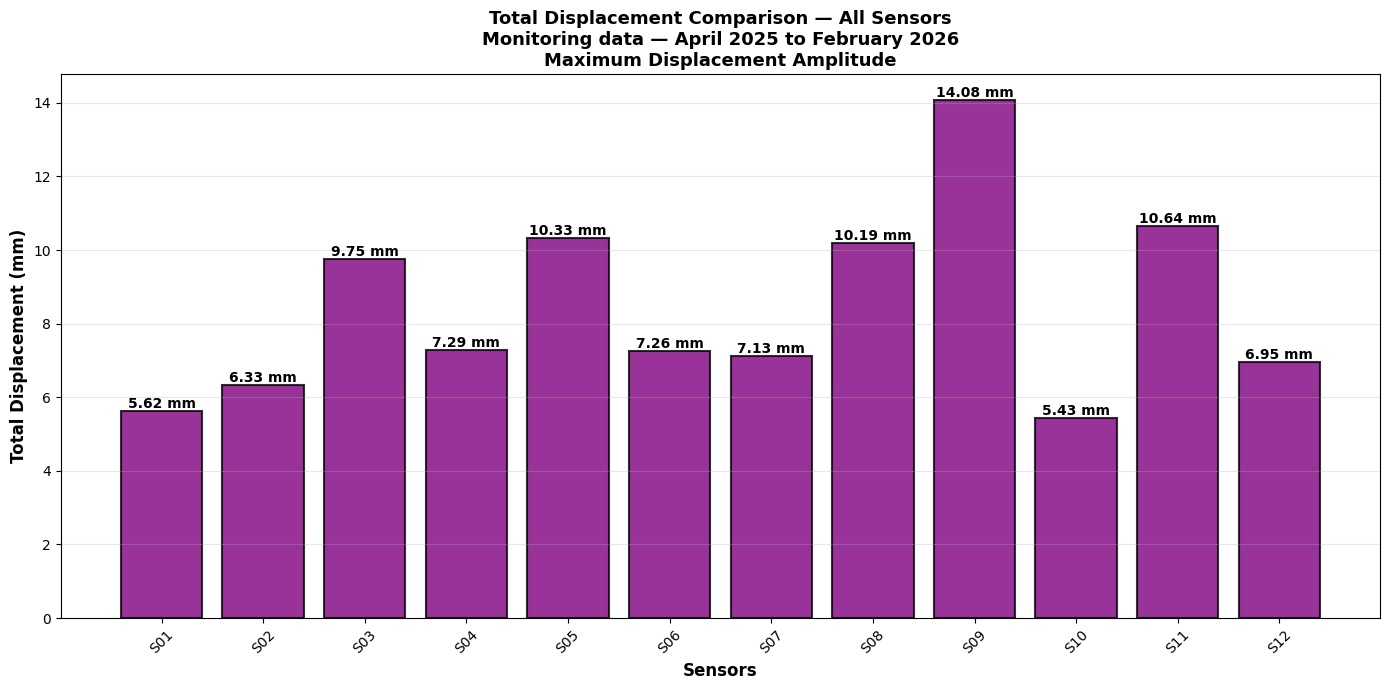

In [6]:
# ============================================================
# 5.1. TOTAL DISPLACEMENT COMPARISON — bar chart
# ============================================================
sensores_ok  = list(resultados_todos.keys())
movimientos  = [resultados_todos[s]['movimiento_total'] for s in sensores_ok]

fig, ax = plt.subplots(figsize=(14, 7))

barras = ax.bar(sensores_ok, movimientos, color='purple', edgecolor='black', linewidth=1.5, alpha=0.8)

for barra, mov in zip(barras, movimientos):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{mov:.2f} mm', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Sensors', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Displacement (mm)', fontsize=12, fontweight='bold')
ax.set_title('Total Displacement Comparison — All Sensors\n'
             'Monitoring data — April 2025 to February 2026\n'
             'Maximum Displacement Amplitude',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(TABLES_PATH, '03_total_displacement_comparison.png'), dpi=300, bbox_inches='tight')
print('Exported: 03_total_displacement_comparison.png')
plt.show()

Exported: 03_std_dev_comparison.png


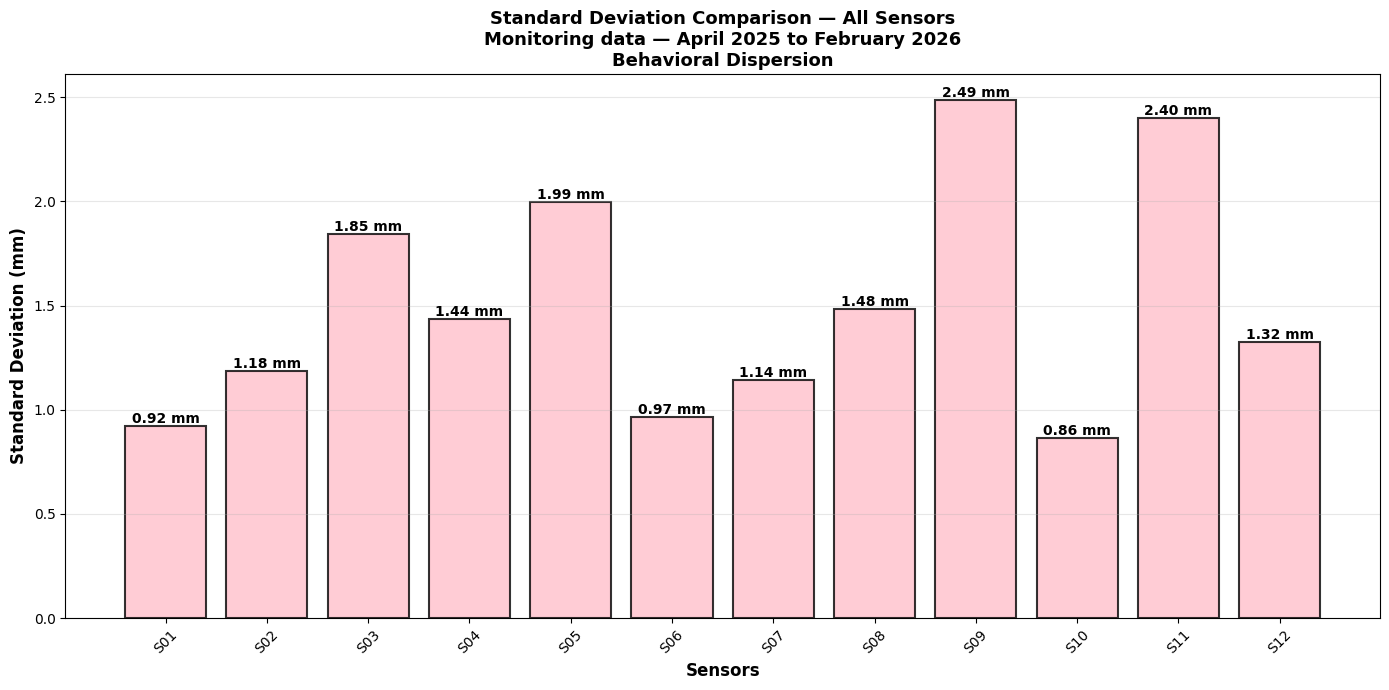

In [7]:
# ============================================================
# 5.2. STD. DEVIATION COMPARISON — bar chart
# ============================================================
desv_est = [resultados_todos[s]['std'] for s in sensores_ok]

fig, ax = plt.subplots(figsize=(14, 7))

barras = ax.bar(sensores_ok, desv_est, color='pink', edgecolor='black', linewidth=1.5, alpha=0.8)

for barra, des in zip(barras, desv_est):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura,
            f'{des:.2f} mm', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Sensors', fontsize=12, fontweight='bold')
ax.set_ylabel('Standard Deviation (mm)', fontsize=12, fontweight='bold')
ax.set_title('Standard Deviation Comparison — All Sensors\n'
             'Monitoring data — April 2025 to February 2026\n'
             'Behavioral Dispersion',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(TABLES_PATH, '03_std_dev_comparison.png'), dpi=300, bbox_inches='tight')
print('Exported: 03_std_dev_comparison.png')
plt.show()

---
## 6. Consolidated Movement Range Table

Built dynamically from `resultados_todos` — replaces the original hardcoded `TablasRangos.ipynb`.
Shows the four percentile bands that define the alert threshold framework:
- 50% central (IQR) = daily structural baseline
- 90% central = seasonal variation envelope
- 95% central = Yellow Alert threshold
- 100% = historical maximum

In [8]:
# ============================================================
# CONSOLIDATED MOVEMENT RANGE TABLE
# Ordered: horizontal sensors first, then diagonal — per zone
# ============================================================

# Define display order: horizontal sensors first within each zone
ORDER = ['S02', 'S04', 'S01', 'S03',   # Zone A: Hor. first, then Diag.
         'S06', 'S08', 'S05', 'S07',   # Zone B
         'S10', 'S12', 'S09', 'S11']   # Zone C

datos_rangos = []
for s in ORDER:
    if s not in resultados_todos:
        continue
    d = resultados_todos[s]
    datos_rangos.append({
        'Sensor'                    : s,
        'Zone'                      : d['zone'],
        'Axis'                      : d['axis'],
        'Mean Displacement (mm)'    : round(d['media'], 2),
        'Coeff. of Variation (%)'   : round(d['coef_var'], 2),
        '50% Central Band (mm)'     : f"{d['Q1']:.2f} – {d['Q3']:.2f}",
        'Amplitude 50% (mm)'        : round(d['IQR'], 2),
        '90% Central (mm)'          : f"{d['p5']:.2f} – {d['p95']:.2f}",
        'Amplitude 90% (mm)'        : round(d['p95'] - d['p5'], 2),
        '95% Central (mm)'          : f"{d['p2_5']:.2f} – {d['p97_5']:.2f}",
        'Amplitude 95% (mm)'        : round(d['p97_5'] - d['p2_5'], 2),
        '100% Total Range (mm)'     : f"0.00 – {d['movimiento_total']:.2f}",
        'Amplitude 100% (mm)'       : round(d['movimiento_total'], 2),
    })

df_rangos = pd.DataFrame(datos_rangos)

print(f"\n{'='*200}")
print(f"CONSOLIDATED MOVEMENT RANGE TABLE")
print(f"Ordered: horizontal sensors first, then diagonal (per zone)")
print(f"{'='*200}\n")
print(df_rangos.to_string(index=False))

# Summary by zone
for zone in ['Zone A', 'Zone B', 'Zone C']:
    df_zone = df_rangos[df_rangos['Zone'] == zone]
    print(f"\n{'─'*120}")
    print(f"{zone.upper()}")
    print(f"{'─'*120}\n")
    print(df_zone[['Sensor', 'Axis', 'Mean Displacement (mm)',
                   'Coeff. of Variation (%)', '50% Central Band (mm)',
                   '100% Total Range (mm)']].to_string(index=False))

df_rangos.to_excel(os.path.join(TABLES_PATH, '03_movement_ranges_consolidated.xlsx'), index=False)
print(f'\nExported: 03_movement_ranges_consolidated.xlsx')


CONSOLIDATED MOVEMENT RANGE TABLE
Ordered: horizontal sensors first, then diagonal (per zone)

Sensor   Zone  Axis  Mean Displacement (mm)  Coeff. of Variation (%) 50% Central Band (mm)  Amplitude 50% (mm) 90% Central (mm)  Amplitude 90% (mm) 95% Central (mm)  Amplitude 95% (mm) 100% Total Range (mm)  Amplitude 100% (mm)
   S02 Zone A  Hor.                    2.58                    45.86           1.92 – 3.00                1.08      1.00 – 5.00                4.00      1.00 – 5.63                4.63           0.00 – 6.33                 6.33
   S04 Zone A  Hor.                    2.44                    58.84           1.33 – 3.09                1.76      0.55 – 5.14                4.59      0.12 – 6.00                5.88           0.00 – 7.29                 7.29
   S01 Zone A Diag.                    2.28                    40.45           1.62 – 2.69                1.07      0.98 – 3.98                3.00      0.76 – 4.62                3.86           0.00 – 5.62              

---
## Summary

This notebook produced:

| Output | Description |
|--------|-------------|
| `02_clean_data_nan_summary.xlsx` | Null value table on clean merged dataset |
| `03_statistics_summary_all_sensors.xlsx` | Descriptive statistics per sensor |
| `03_movement_ranges_consolidated.xlsx` | Percentile band table — basis for alert thresholds |
| `03_total_displacement_comparison.png` | Comparative bar chart — total displacement |
| `03_std_dev_comparison.png` | Comparative bar chart — standard deviation |

**Alert threshold framework derived from this analysis:**
- **Yellow alert:** displacement exceeds 95% central band (P97.5)
- **Red alert:** displacement exceeds mean + 3σ (approx. > 11.5 mm on critical axes)
- **Hysteresis alert:** structure fails to return to nocturnal baseline (04:00–06:00 AM)

**Next:** `04_correlation_analysis.ipynb` — Pearson correlation matrices per zone and per axis group.